In [1]:
import numpy as np
import networkx as nx

from scipy.integrate import solve_ivp

from replicator_net import ODReplicatorNetwork

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# GRAPH GENERATION
# ============================================================

# np.random.seed(1)

G_grid = nx.grid_2d_graph(9, 9)
G = nx.convert_node_labels_to_integers(
    G_grid,
    label_attribute="coord",
)

# keep geometric positions from original grid coordinates
pos = {n: data["coord"] for n, data in G.nodes(data=True)}

edges = list(G.edges())
E = len(edges)

print(f"Nodes: {G.number_of_nodes()}, Edges: {E}")

# Same graph for all modes
graphs = [
    G.copy(),  # car
    G.copy(),  # bike
    G.copy(),  # transit
]

mode_names = ["car", "bike", "transit"]
mode_colors = {"car": "tab:red", "bike": "tab:green", "transit": "tab:blue"}
mode_cmaps = {"car": plt.cm.Reds, "bike": plt.cm.Greens, "transit": plt.cm.Blues}
K = len(mode_names)

# ============================================================
# ZONES / OD PAIRS
# ============================================================

zones = [0, 3, 5, 10, 12, 15]
print(f"Zones: {zones}")
print(f"Directed OD pairs: {len(zones) * (len(zones) - 1)}")

# ============================================================
# EDGE PARAMETERS
# ============================================================

# lengths = np.random.exponential(scale=200.0, size=E)  # meters
lengths = np.ones(E) * 100.0  # uniform lengths for simplicity
# just 1 lane per edge for simplicity, can be randomized if desired
n_lanes = np.ones(E, dtype=int)
vehicle_length = 10.0  # meters
transit_vehicle_length = 10.0  # meters
bike_length = 10.0  # meters

# Mode-dependent capacities: vehicles per edge per mode
capacities_car = lengths * n_lanes / vehicle_length
capacities_bike = lengths * n_lanes / bike_length
capacities_transit = lengths * n_lanes / transit_vehicle_length
capacities = np.column_stack([capacities_car, capacities_bike, capacities_transit])  # shape (E,K)

# car_speed = np.full(E, 50.0 / 3.6)  # 50 km/h → m/s
car_speed = np.random.normal(loc=50.0 / 3.6, scale=5.0 / 3.6, size=E)  # add some variability to speeds
# bike_speed = np.full(E, 12.0 / 3.6)  # 12 km/h → m/s
bike_speed = np.random.normal(loc=12.0 / 3.6, scale=2.0 / 3.6, size=E)  # add some variability to speeds
# transit_speed = np.full(E, 25.0 / 3.6)  # 25 km/h → m/s
transit_speed = np.random.normal(loc=25.0 / 3.6, scale=5.0 / 3.6, size=E)  # add some variability to speeds
free_flow_speeds = np.column_stack([car_speed, bike_speed, transit_speed])  # shape (E,K)

interaction_matrix = np.array([
    [60.0,  5.0, 10.0],   # impact on su car from [car, bike, transit] (s per unit density)
    [ 2.0, 10.0,  3.0],   # impact on bike
    [10.0,  5.0, 30.0],   # impact on transit
])

# pick a small set of zones from graph nodes
nodes = list(G.nodes())
if len(nodes) <= 6:
    zones = nodes
else:
    zones = list(np.random.choice(nodes, size=9, replace=False))
print('Zones:', zones)

# build model
model = ODReplicatorNetwork(
    multilayer_graphs=graphs,
    zones=zones,
    edge_lengths=lengths,
    edge_capacities=capacities,
    free_flow_speeds=free_flow_speeds,
    rho=0.001,
    interaction_matrix=interaction_matrix,
    od_demands=np.random.uniform(1, 1, size=(len(zones) * (len(zones) - 1),))
)

initialization_method = 'uniform'  # options: 'random', 'uniform', 'custom'

if initialization_method == 'uniform':
    x0 = np.full((model.N_od, model.K), 1.0 / model.K)

elif initialization_method == 'custom':
    x0 = np.zeros((model.N_od, model.K))
    for od in range(model.N_od):
        x0[od, od % model.K] = 1.0  # assign each OD to a single mode in round-robin fashion
else:
    # random initial shares per OD, row-normalized
    x0 = np.random.rand(model.N_od, model.K)

x0 = x0 / x0.sum(axis=1, keepdims=True)
print(f'Running simulation... (N_od={model.N_od}, K={model.K})')

t, X = model.simulate(x0, t_span=(0, 200), n_steps=400)

print('Simulation finished. t points:', len(t))

Nodes: 81, Edges: 144
Zones: [0, 3, 5, 10, 12, 15]
Directed OD pairs: 30
Zones: [np.int64(25), np.int64(51), np.int64(12), np.int64(59), np.int64(54), np.int64(76), np.int64(35), np.int64(53), np.int64(73)]
Running simulation... (N_od=72, K=3)
solve_ivp success: True
message: The solver successfully reached the end of the integration interval.
Simulation finished. t points: 400


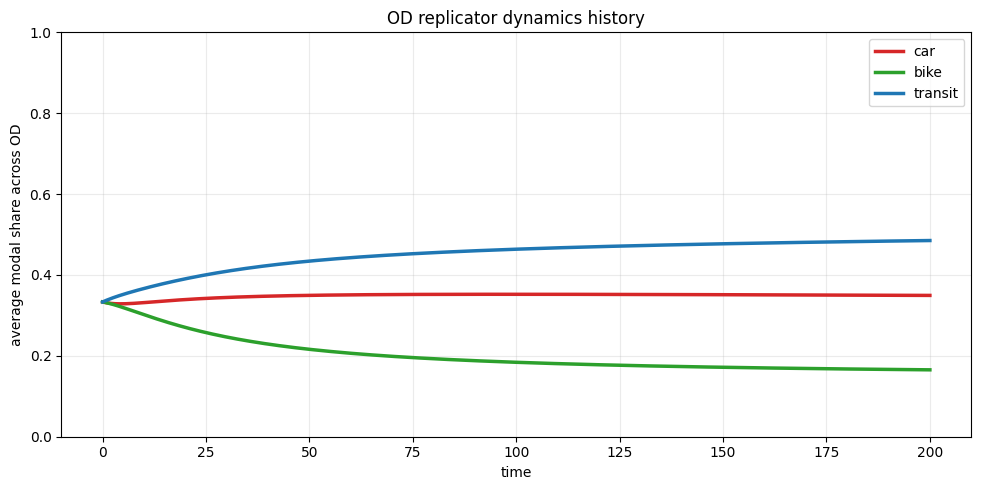

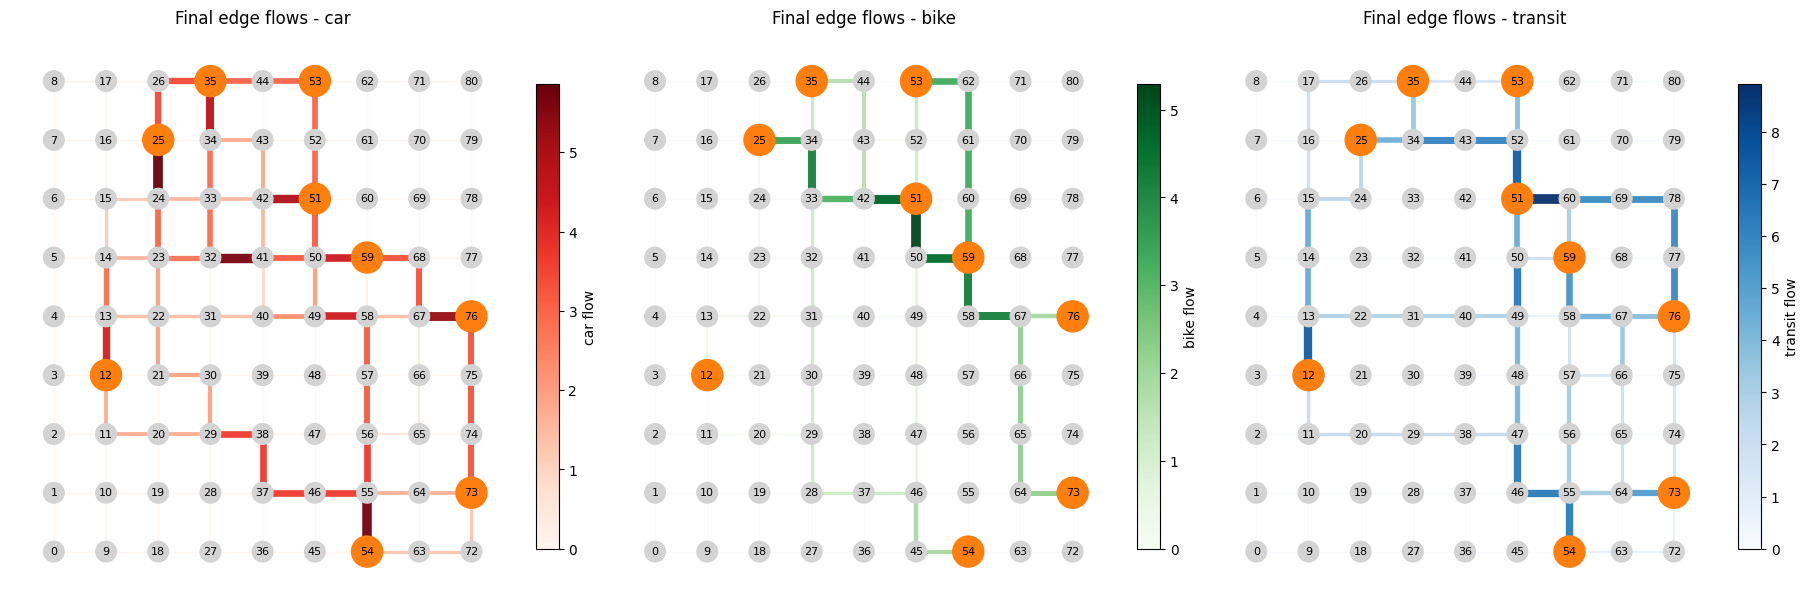


Final average modal shares:
car: 0.3494
bike: 0.1654
transit: 0.4851

Top 5 edges by final aggregate flow:
edge (50, 51) -> flow 13.0258
edge (54, 55) -> flow 12.1089
edge (12, 13) -> flow 12.0000
edge (51, 52) -> flow 11.5038
edge (67, 76) -> flow 11.0512


In [3]:
# ============================================================
# PLOT: DYNAMICS HISTORY
# ============================================================

# average modal share across all OD pairs over time
mode_history = X.mean(axis=1)  # shape (T, K)

plt.figure(figsize=(10, 5))
for m, name in enumerate(mode_names):
    plt.plot(
        t,
        mode_history[:, m],
        label=name,
        linewidth=2.5,
        color=mode_colors[name],
    )

plt.xlabel("time")
plt.ylabel("average modal share across OD")
plt.title("OD replicator dynamics history")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)  # modal shares are between 0 and 1
plt.show()

# ============================================================
# PLOT: GRAPH WITH FLOWS BY MODE (different colors)
# ============================================================

x_final = X[-1]

# flow per edge and mode
final_mode_flows = np.zeros((model.E, model.K))
for od in range(model.N_od):
    for m in range(model.K):
        share = x_final[od, m]
        path = model.paths[(od, m)]
        for e in path:
            final_mode_flows[e, m] += share

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for m, ax in enumerate(axes):
    mode_name = mode_names[m]
    edge_values = final_mode_flows[:, m]

    norm = plt.Normalize(vmin=edge_values.min(), vmax=edge_values.max() + 1e-12)
    edge_widths = 1.0 + 6.0 * norm(edge_values)
    # Color nodes: OD zones in orange, others in gray
    node_colors = ['tab:orange' if n in zones else 'lightgray' for n in G.nodes()]
    node_sizes = [500 if n in zones else 220 for n in G.nodes()]

    '''nx.draw_networkx_nodes(
        G, pos=pos, node_size=node_sizes, node_color=node_colors
    )
    nx.draw_networkx_labels(
        G, pos=pos, font_size=8, font_weight='bold'
    )'''
    nx.draw_networkx_nodes(
        G, pos=pos, node_size=node_sizes, node_color=node_colors, ax=ax
    )
    nx.draw_networkx_labels(
        G, pos=pos, font_size=8, ax=ax
    )
    nx.draw_networkx_edges(
        G,
        pos=pos,
        edgelist=edges,
        width=edge_widths,
        edge_color=edge_values,
        edge_cmap=mode_cmaps[mode_name],
        alpha=0.95,
        ax=ax,
    )

    sm = plt.cm.ScalarMappable(cmap=mode_cmaps[mode_name], norm=norm)
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label=f"{mode_name} flow")

    ax.set_title(f"Final edge flows - {mode_name}")
    ax.axis("off")

plt.show()

# ============================================================
# QUICK NUMERIC SUMMARY
# ============================================================

print("\nFinal average modal shares:")
for m, name in enumerate(mode_names):
    print(f"{name}: {mode_history[-1, m]:.4f}")

agg_flows = final_mode_flows.sum(axis=1)
top_edges = np.argsort(agg_flows)[-5:][::-1]
print("\nTop 5 edges by final aggregate flow:")
for idx in top_edges:
    print(f"edge {edges[idx]} -> flow {agg_flows[idx]:.4f}") 

# one mode trial

In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# GRAPH GENERATION
# ============================================================
# np.random.seed(1)
G_grid = nx.grid_2d_graph(9, 9)
G = nx.convert_node_labels_to_integers(
    G_grid,
    label_attribute="coord",
)

# keep geometric positions from original grid coordinates
pos = {n: data["coord"] for n, data in G.nodes(data=True)}
edges = list(G.edges())
E = len(edges)
print(f"Nodes: {G.number_of_nodes()}, Edges: {E}")

# Single graph for car only
graphs = [G.copy()]
mode_names = ["car"]
mode_colors = {"car": "tab:red"}
mode_cmaps = {"car": plt.cm.Reds}
K = len(mode_names)  # K = 1

# ============================================================
# ZONES / OD PAIRS
# ============================================================
zones = [0, 3, 5, 10, 12, 15]
print(f"Zones: {zones}")
print(f"Directed OD pairs: {len(zones) * (len(zones) - 1)}")

# ============================================================
# EDGE PARAMETERS
# ============================================================
lengths = np.ones(E) * 100.0  # uniform lengths for simplicity
n_lanes = np.ones(E, dtype=int)
vehicle_length = 10.0  # meters

# Car-only capacity
capacities_car = lengths * n_lanes / vehicle_length
capacities = capacities_car.reshape(-1, 1)  # shape (E, 1)

car_speed = np.random.normal(loc=50.0 / 3.6, scale=5.0 / 3.6, size=E)
free_flow_speeds = car_speed.reshape(-1, 1)  # shape (E, 1)

# 1x1 interaction matrix (car only)
interaction_matrix = np.array([
    [60.0],  # impact on car from [car]
])

# Pick a small set of zones from graph nodes
nodes = list(G.nodes())
if len(nodes) <= 6:
    zones = nodes
else:
    zones = list(np.random.choice(nodes, size=9, replace=False))
print('Zones:', zones)

# Build model
model = ODReplicatorNetwork(
    multilayer_graphs=graphs,
    zones=zones,
    edge_lengths=lengths,
    edge_capacities=capacities,
    free_flow_speeds=free_flow_speeds,
    rho=0.001,
    interaction_matrix=interaction_matrix,
    od_demands=np.random.uniform(1, 1, size=(len(zones) * (len(zones) - 1),))
)

# With K=1, all demand goes to car — initialization is trivial
x0 = np.ones((model.N_od, model.K))  # shape (N_od, 1), all share = 1.0

print(f'Running simulation... (N_od={model.N_od}, K={model.K})')
t, X = model.simulate(x0, t_span=(0, 200), n_steps=400)
print('Simulation finished. t points:', len(t))

Nodes: 81, Edges: 144
Zones: [0, 3, 5, 10, 12, 15]
Directed OD pairs: 30
Zones: [np.int64(57), np.int64(49), np.int64(11), np.int64(21), np.int64(61), np.int64(29), np.int64(19), np.int64(17), np.int64(70)]
Running simulation... (N_od=72, K=1)
solve_ivp success: True
message: The solver successfully reached the end of the integration interval.
Simulation finished. t points: 400


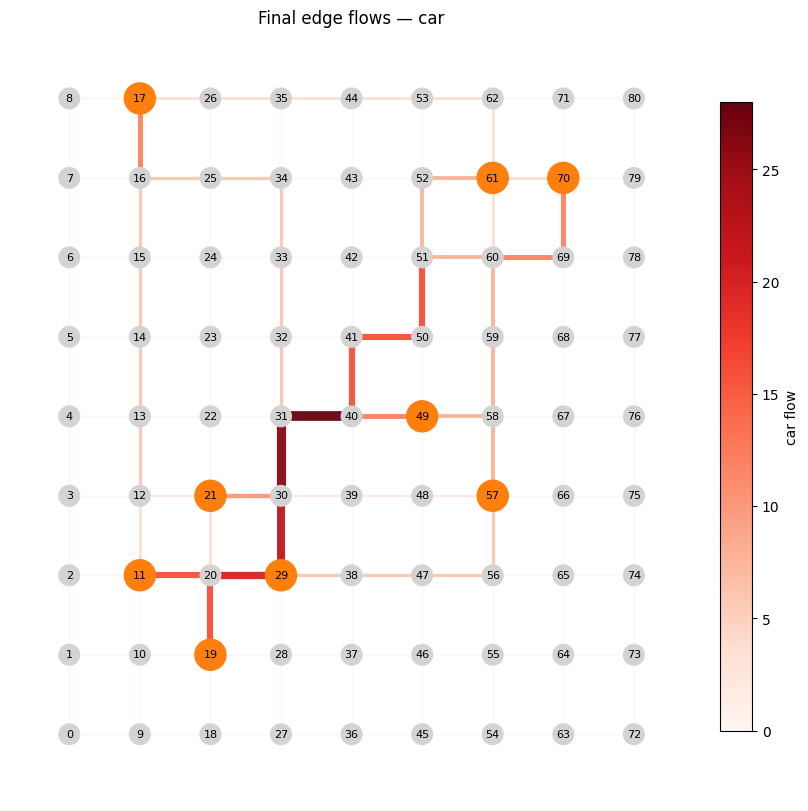


Final average modal share:
car: 1.0000

Top 5 edges by final car flow:
  edge (31, 40) -> flow 28.0000
  edge (30, 31) -> flow 26.0000
  edge (29, 30) -> flow 22.0000
  edge (20, 29) -> flow 20.0000
  edge (19, 20) -> flow 16.0000


In [5]:
# ============================================================
# PLOT: GRAPH WITH FLOWS — CAR ONLY (single panel)
# ============================================================
x_final = X[-1]

# flow per edge (car only)
final_car_flows = np.zeros(model.E)
for od in range(model.N_od):
    share = x_final[od, 0]
    path = model.paths[(od, 0)]
    for e in path:
        final_car_flows[e] += share

fig, ax = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)

norm = plt.Normalize(vmin=final_car_flows.min(), vmax=final_car_flows.max() + 1e-12)
edge_widths = 1.0 + 6.0 * norm(final_car_flows)

# Color nodes: OD zones in orange, others in gray
node_colors = ['tab:orange' if n in zones else 'lightgray' for n in G.nodes()]
node_sizes  = [500 if n in zones else 220 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos=pos, node_size=node_sizes, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos=pos, font_size=8, ax=ax)
nx.draw_networkx_edges(
    G,
    pos=pos,
    edgelist=edges,
    width=edge_widths,
    edge_color=final_car_flows,
    edge_cmap=mode_cmaps["car"],
    alpha=0.95,
    ax=ax,
)

sm = plt.cm.ScalarMappable(cmap=mode_cmaps["car"], norm=norm)
plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label="car flow")
ax.set_title("Final edge flows — car")
ax.axis("off")
plt.show()

# ============================================================
# QUICK NUMERIC SUMMARY
# ============================================================
print("\nFinal average modal share:")
print(f"car: {X.mean(axis=1)[-1, 0]:.4f}")

top_edges = np.argsort(final_car_flows)[-5:][::-1]
print("\nTop 5 edges by final car flow:")
for idx in top_edges:
    print(f"  edge {edges[idx]} -> flow {final_car_flows[idx]:.4f}")

# analysis

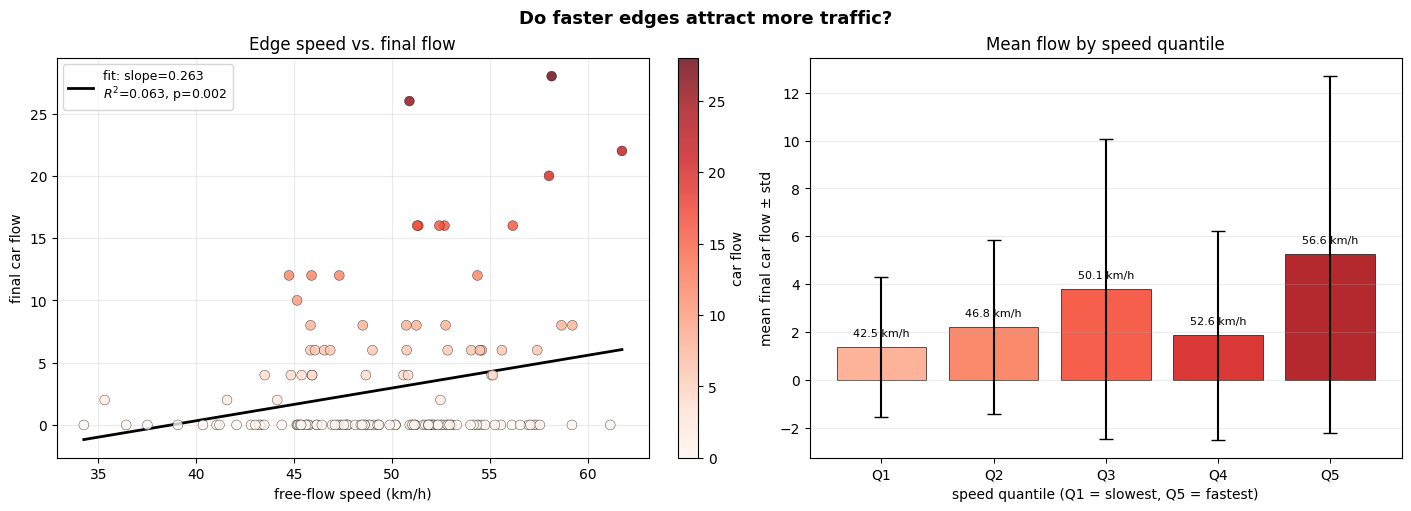


Linear regression — speed (km/h) → flow
  slope     : 0.2631
  R²        : 0.0631
  p-value   : 0.0024
  Significant positive correlation (α=0.05)


In [6]:
# ============================================================
# PLOT: EDGE SPEED vs FINAL FLOW (scatter + regression)
# ============================================================
from scipy import stats
import pandas as pd

# free_flow_speeds has shape (E, 1) — squeeze to 1-D
edge_speeds = free_flow_speeds[:, 0]          # m/s
edge_speeds_kmh = edge_speeds * 3.6           # km/h for readability

flow = final_car_flows                        # already 1-D, shape (E,)

# linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(edge_speeds_kmh, flow)
fit_x = np.linspace(edge_speeds_kmh.min(), edge_speeds_kmh.max(), 200)
fit_y = slope * fit_x + intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# --- left panel: scatter + regression line ---
ax = axes[0]
sc = ax.scatter(
    edge_speeds_kmh, flow,
    c=flow,
    cmap=plt.cm.Reds,
    edgecolors="k",
    linewidths=0.3,
    alpha=0.8,
    s=50,
    zorder=3,
)
ax.plot(fit_x, fit_y, color="black", linewidth=2,
        label=f"fit: slope={slope:.3f}\n$R^2$={r_value**2:.3f}, p={p_value:.3f}")
plt.colorbar(sc, ax=ax, label="car flow")
ax.set_xlabel("free-flow speed (km/h)")
ax.set_ylabel("final car flow")
ax.set_title("Edge speed vs. final flow")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# --- right panel: edges binned by speed quantile ---
ax = axes[1]
n_bins = 5
labels = [f"Q{i+1}" for i in range(n_bins)]
quantile_bins = pd.qcut(edge_speeds_kmh, q=n_bins, labels=labels)

bin_means  = [flow[quantile_bins == lbl].mean() for lbl in labels]
bin_stds   = [flow[quantile_bins == lbl].std()  for lbl in labels]
bin_speeds = [edge_speeds_kmh[quantile_bins == lbl].mean() for lbl in labels]

bars = ax.bar(labels, bin_means, yerr=bin_stds,
              color=plt.cm.Reds(np.linspace(0.3, 0.85, n_bins)),
              edgecolor="k", linewidth=0.5,
              capsize=5, alpha=0.9)

# annotate bars with mean speed
for bar, spd in zip(bars, bin_speeds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(bin_stds) * 0.05,
            f"{spd:.1f} km/h", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("speed quantile (Q1 = slowest, Q5 = fastest)")
ax.set_ylabel("mean final car flow ± std")
ax.set_title("Mean flow by speed quantile")
ax.grid(axis="y", alpha=0.25)

plt.suptitle("Do faster edges attract more traffic?", fontsize=13, fontweight="bold")
plt.show()

print(f"\nLinear regression — speed (km/h) → flow")
print(f"  slope     : {slope:.4f}")
print(f"  R²        : {r_value**2:.4f}")
print(f"  p-value   : {p_value:.4f}")
print(f"  {'Significant positive correlation' if slope > 0 and p_value < 0.05 else 'No significant correlation'} (α=0.05)")